<div class="alert alert-block alert-info" style="margin-top: 20px">

__Ms.MRUNALINI (Data Science Trainer)__
📧 mrunalini0107@gmail.com
📍 Mumbai–400095

<div class="alert alert-block alert-info" style="margin-top: 20px">

## 📘 Simulation of Statistical Models - FACTORIAL ANOVA

### 📌 FACTORIAL ANOVA
Factorial ANOVA (with and without interaction).

#### 📊 Model Form (Two-Way ANOVA)

Without interaction:
* Without interaction: $Y_{ijk​ }= μ + α_i​ + β_j​ + ε_{ijk}$​

* With interaction: $Y_{ijk}​ =  μ +  α_i​ + β_j​ + (αβ)_{ij}  + ε_{ijk}$​

where $ε_{ijk}​∼N(0,σ^2)$

Two fixed-effect factors:

* Fact1 → 2 levels (A, B)
* Fact2 → 3 levels (a, b, c)
* Balanced design: 6 replications per combination

### 🔹 PART 1: Factorial ANOVA WITHOUT Interaction
Step 1: Define Factors (Balanced Design)

In [24]:
# Factor 1 (2 levels)
Fact1 <- gl(2, 18, labels = c("A", "B"))

# Factor 2 (3 levels, repeated within Fact1)
Fact2 <- gl(3, 6, 36, labels = c("a", "b", "c"))

# Check balance (6 replications per cell)
table(Fact1, Fact2)


     Fact2
Fact1 a b c
    A 6 6 6
    B 6 6 6

This will produce a balanced 2×3 table with 6 replications per cell.

Step 2: Assign Cell Means (No Interaction)

In [25]:
# Base means for Fact1
Fact1N <- rep(c(3, 4), each = 18)

# Add same shifts (-1, 0, +1) for both levels of Fact1
Fact2N <- rep(c(-1, 0, 1), each = 6, times = 2)

# Check combined means
data.frame(Fact1N, Fact2N,
           Sum = Fact1N + Fact2N)


Fact1N,Fact2N,Sum
<dbl>,<dbl>,<dbl>
3,-1,2
3,-1,2
3,-1,2
3,-1,2
3,-1,2
3,-1,2
3,0,3
3,0,3
3,0,3


👉 Since shifts are identical for A and B → no interaction

Step 3: Plot Deterministic Means

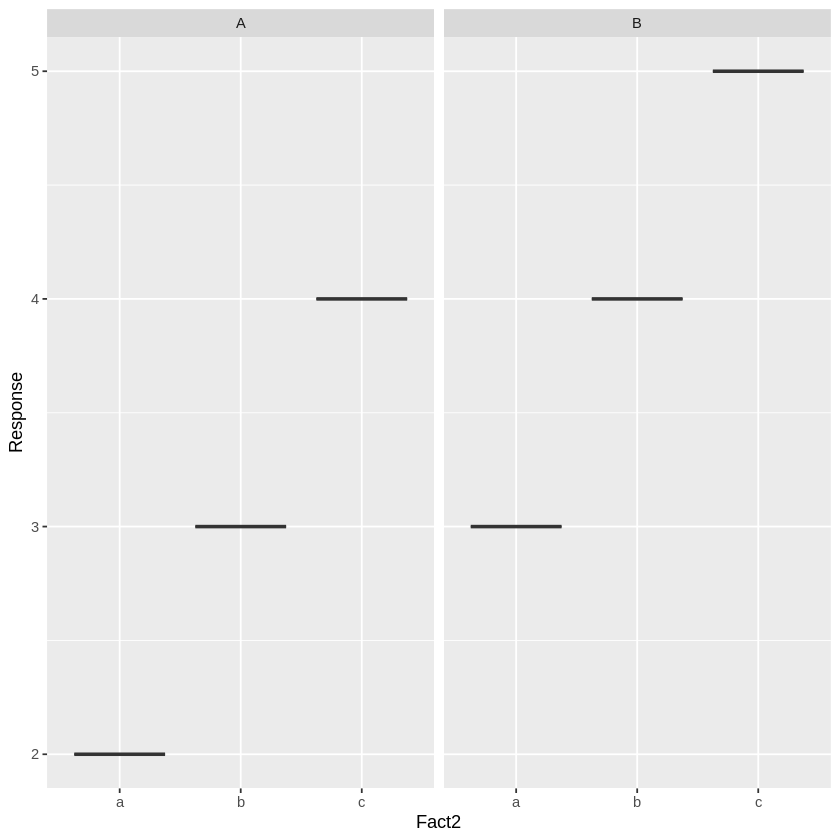

In [26]:
# Factorial ANOVA (Without Interaction)
# Plot Deterministic Cell Means

library(ggplot2)   # Load ggplot2 package

# Create response from main effects only
Response <- Fact1N + Fact2N

# Combine into data frame
Factorial1a <- data.frame(Response, Fact1, Fact2)

# Boxplot visualization (faceted by Fact1)
ggplot(Factorial1a, aes(x=Fact2, y=Response)) +
  geom_boxplot() +
  facet_grid(. ~ Fact1)

👉 Interpretation: Parallel pattern → only main effects.

Interpretation:

* Each panel represents one level of Fact1.
* Within each panel, boxplots show levels of Fact2.
* Since Fact2 shifts are identical across Fact1, the pattern is parallel → no interaction.

Step 4: Add Residual Variation

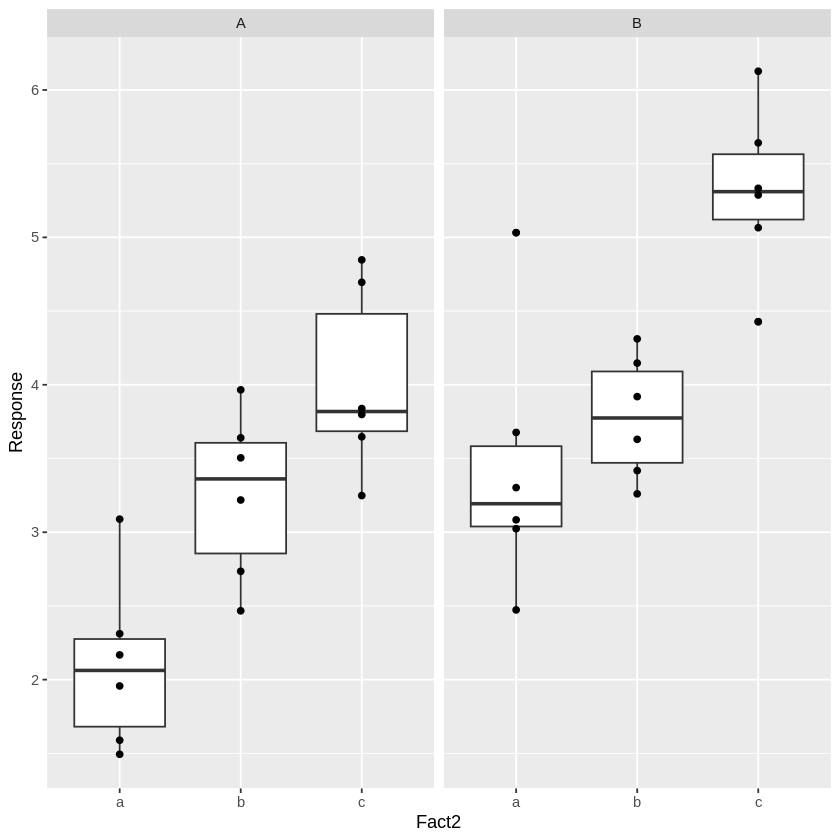

In [27]:
# Factorial ANOVA (Without Interaction)
# Add Residual Variation and Visualize

set.seed(635)   # Reproducibility

SD <- 0.6       # Standard deviation of residuals

# Generate random errors ~ N(0, 0.6^2)
residuals <- rnorm(n = length(Response),
                   mean = 0,
                   sd = SD)

# Add residual variation to main effects
Response <- Fact1N + Fact2N + residuals

# Combine into data frame
Factorial1b <- data.frame(Response, Fact1, Fact2)

# Visualize with boxplots and raw data points
library(ggplot2)

ggplot(Factorial1b,
       aes(x = Fact2,
           y = Response)) +
  geom_boxplot() +
  geom_point() +
  facet_grid(. ~ Fact1)

Interpretation:

* Residual variation introduces realistic spread.
* Patterns across panels remain parallel.
* This indicates main effects only, no interaction.

Step 5: Fit ANOVA Model

To performs a two-way ANOVA with interaction, based on the model:

$Y_{ijk}​ =  μ +  α_i​ + β_j​ + (αβ)_{ij}  + ε_{ijk}$

Where:
* μ → overall mean
* $α_i$ → effect of Factor 1 (Fact1)
* $β_j​ $ → effect of Factor 2 (Fact2)
* $(αβ)_{ij}$ → interaction effect
* $ε_{ijk}∼N(0,σ^2)$


In [28]:
# Perform Two-Way ANOVA with interaction
# Using dataset: Factorial1b

summary(aov(Response ~ Fact1 + Fact2 + Fact1:Fact2,
            data = Factorial1b))

            Df Sum Sq Mean Sq F value   Pr(>F)    
Fact1        1  9.970   9.970  25.870 1.83e-05 ***
Fact2        2 21.888  10.944  28.398 1.20e-07 ***
Fact1:Fact2  2  1.249   0.625   1.621    0.215    
Residuals   30 11.562   0.385                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Interpretation:

Fact1

* Tests whether different levels of Factor 1 have different means.
* If p-value < 0.05 → significant main effect.

Fact2

* Tests whether different levels of Factor 2 have different means.
* If p-value < 0.05 → significant main effect.

Fact1:Fact2 (Interaction)

* Tests whether the effect of Fact1 depends on Fact2.
* If significant → interaction present.
* In this case, interpret interaction before main effects.

Residuals
* Estimates experimental error variance.

### 🔹 PART 2: Factorial ANOVA WITH Interaction

Now we modify one level of Fact2 differently under Fact1 = B.

Step 1: Define Factors Again

In [29]:
# Create Factor 1 (Fact1)
# gl(n, k, length, labels)
# n = number of levels
# k = number of repetitions for each level
# labels = names of the levels

Fact1 <- gl(2, 18, labels = c("A", "B"))
# This creates a factor with:
# 2 levels ("A" and "B")
# Each level repeated 18 times
# Total observations = 36


# Create Factor 2 (Fact2)
# gl(n, k, length, labels)
# n = number of levels
# k = number of repetitions of each level
# length = total number of observations
# labels = names of the levels

Fact2 <- gl(3, 6, 36, labels = c("a", "b", "c"))
# This creates a factor with:
# 3 levels ("a", "b", "c")
# Each level repeated 6 times before switching
# Total length fixed at 36 observations


To Creates (Factorial Structure)

* Fact1 → 2 levels (A, B)
* Fact2 → 3 levels (a, b, c)
* Total observations = 36
* This corresponds to a 2 × 3 factorial design
* Replications per treatment combination = $36/2×3=6$

So you have 6 replicates per cell.

Step 2: Assign Means (Introduce Interaction)

In [30]:
# Base means
Fact1N <- rep(c(3, 4), each = 18)

# Different shifts for B (interaction introduced)
Fact2N <- rep(c(-1, 0, 1,   # For A
                -1, 0, 0),  # For B
              each = 6)

data.frame(Fact1N, Fact2N,
           Mean = Fact1N + Fact2N)


Fact1N,Fact2N,Mean
<dbl>,<dbl>,<dbl>
3,-1,2
3,-1,2
3,-1,2
3,-1,2
3,-1,2
3,-1,2
3,0,3
3,0,3
3,0,3


👉 Now at least one level changes differently → interaction present

Step 3: Plot Deterministic Means

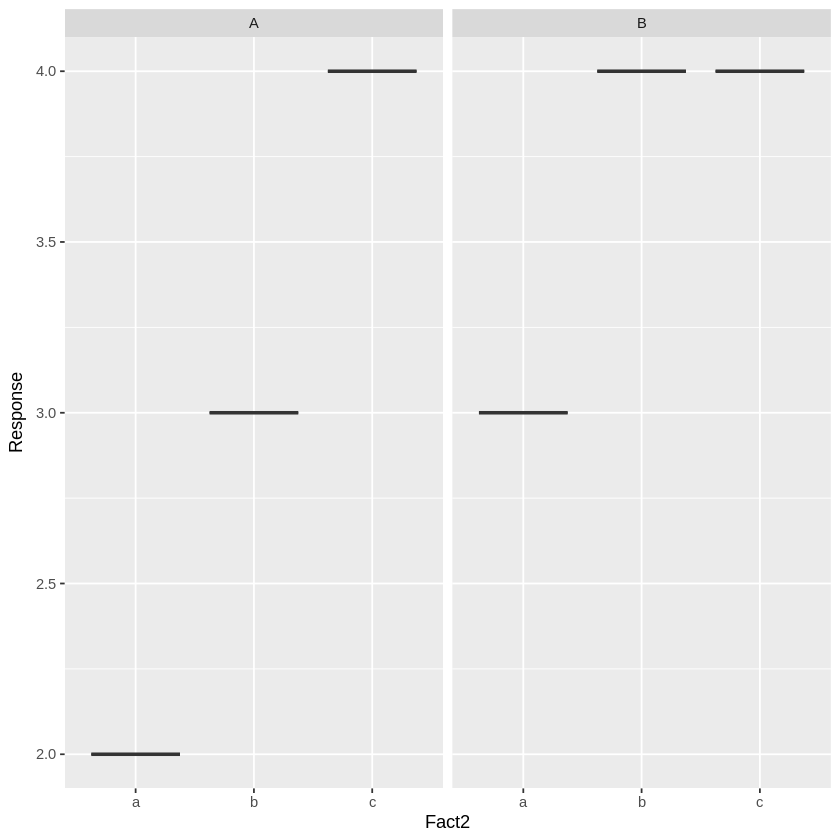

In [31]:
# Create the response variable as the sum of numeric effects
# Fact1N = numeric effect of Factor 1
# Fact2N = numeric effect of Factor 2
# This represents an additive model (no interaction, no random error)
Response <- Fact1N + Fact2N


# Combine Response and factors into a data frame
# This creates the dataset for analysis and plotting
Factorial2a <- data.frame(Response, Fact1, Fact2)


# Load ggplot2 for visualization
library(ggplot2)

# Create boxplots of Response across levels of Fact2
# aes(Fact2, Response) → x-axis = Fact2, y-axis = Response
# facet_grid(. ~ Fact1) → separate panels for each level of Fact1

ggplot(Factorial2a, aes(Fact2, Response)) +
  geom_boxplot() +              # Draw boxplots
  facet_grid(. ~ Fact1)         # Create separate plots for Fact1 levels

### ✅ Represents Statistically

Since: Response = Fact1N + Fact2N

This corresponds to a two-way additive model without interaction:
$Y_{ij​ }= μ + α_i​ + β_j​ $

✔ Main effects present

✖ No interaction

✖ No random error

✅ So the boxplots will show:
* Parallel shifts between panels
* Clear additive pattern
* No variability within groups (if no noise added)

Step 4: Add Residual Variation

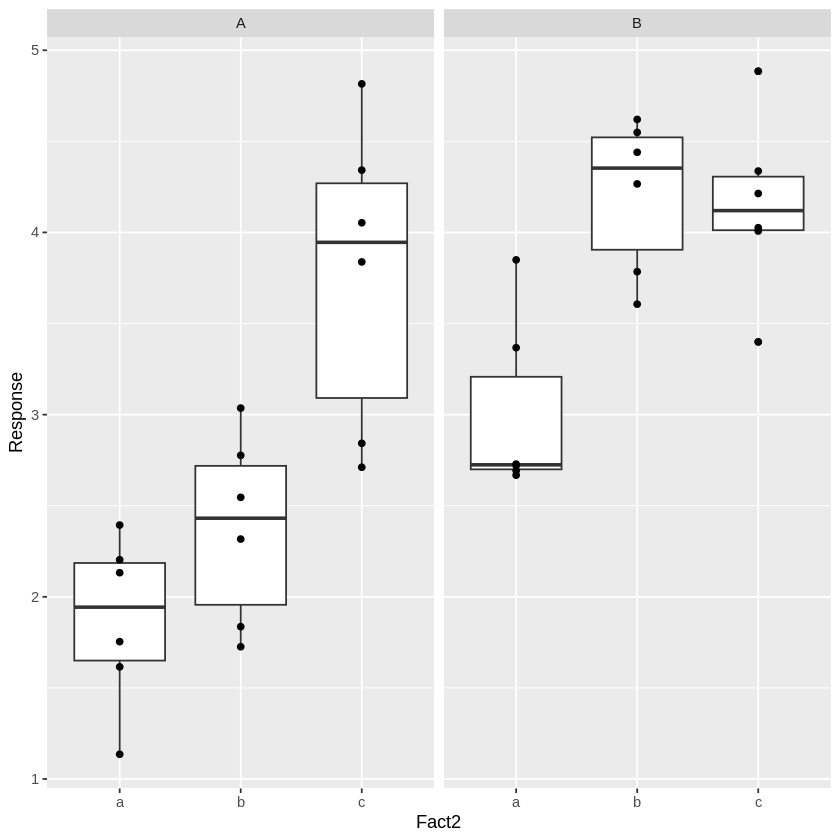

In [32]:
# Set seed for reproducibility
# This ensures the same random numbers are generated every time
set.seed(567)

# Define the standard deviation of random error
SD <- 0.6

# Generate random residual errors
# rnorm(n, mean, sd)
# n = number of observations
# mean = 0 (mean of error term)
# sd = 0.6 (error variability)
residuals <- rnorm(length(Response), 0, SD)

# Create the response variable including random error
# This now represents a realistic two-way factorial model
# with additive effects + random noise
Response <- Fact1N + Fact2N + residuals

# Combine Response and factors into a data frame
Factorial2b <- data.frame(Response, Fact1, Fact2)

# Load ggplot2 for visualization
library(ggplot2)

# Create boxplots of Response across levels of Fact2
# geom_boxplot() → shows distribution within each group
# geom_point() → shows individual observations
# facet_grid(. ~ Fact1) → separate panels for Fact1 levels

ggplot(Factorial2b, aes(Fact2, Response)) +
  geom_boxplot() +        # Boxplots for each Fact2 level
  geom_point() +          # Overlay raw data points
  facet_grid(. ~ Fact1)   # Separate panels by Fact1


### ✅ Represents Statistically

Now your model is: $Y_{ijk​ }= μ + α_i​ + β_j​ + ε_{ijk}$​

where:
* $α_i$ → effect of Fact1
* $β_j​ $ → effect of Fact2
* $ε_{ijk}∼N(0,0.6^2)$​

✔ Main effects present

✖ No interaction

✔ Random variation included


#### ✅ What Will Change in the Plot?
Compared to your previous plot:

* Boxes will now have spread (due to random error)
* Points will not lie exactly on straight lines
* Still no interaction pattern (panels should remain roughly parallel)

Step 5: Fit ANOVA Model

In [33]:
# Perform Two-Way ANOVA including interaction
# Model: Response ~ Fact1 + Fact2 + Fact1:Fact2
# Fact1        → Main effect of Factor 1
# Fact2        → Main effect of Factor 2
# Fact1:Fact2  → Interaction effect between the two factors

summary(aov(Response ~ Fact1 + Fact2 + Fact1:Fact2,
            data = Factorial2b))


            Df Sum Sq Mean Sq F value   Pr(>F)    
Fact1        1 11.208  11.208  36.639 1.20e-06 ***
Fact2        2 13.888   6.944  22.700 9.91e-07 ***
Fact1:Fact2  2  3.201   1.600   5.232   0.0112 *  
Residuals   30  9.177   0.306                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

#### ✅ This Model Represents

This corresponds to the full two-way ANOVA model:
$Y_{ijk}​ =  μ +  α_i​ + β_j​ + (αβ)_{ij}  + ε_{ijk}$​

where:
* $α_i$ → effect of Fact1
* $β_j​ $ → effect of Fact2
* $(αβ)_{ij}$ → Interaction effect
* $ε_{ijk}∼N(0, σ^2)$​


✅ Since you generated the data as:
$Response = Fact1N + Fact2N + residuals$

✔ Fact1 → Significant

✔ Fact2 → Significant

✖ Fact1:Fact2 → Not significant (because no interaction was added)


#####  ✅ So in the ANOVA table:

| Source      | Expected Result |
| ----------- | --------------- |
| Fact1       | Small p-value   |
| Fact2       | Small p-value   |
| Interaction | Large p-value   |
| Residuals   | Random error    |


### ✅ Summary

| Model Type          | Main Effects | Interaction | Graph Pattern |
| ------------------- | ------------ | ----------- | ------------- |
| Without Interaction | Yes          | No          | Parallel      |
| With Interaction    | Yes          | Yes         | Non-parallel  |


<div class="alert alert-block alert-info" style="margin-top: 20px">
    
### THANK YOU ...! 
    
__Ms.MRUNALINI (Data Science Trainer)__
📧 mrunalini0107@gmail.com
📍 Mumbai–400095